# Preprocesamiento de datos — Laboratorio de Análisis Clínico
**Asignatura:** Laboratorio de Optimización  
**Objetivo:** Analizar el volumen y distribución de peticiones del mes de enero para informar el modelo de optimización de asignación de pruebas a analizadores (DX1, DX2, DX3).

---

## 0. Importaciones y configuración

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
import xlrd

# Estilo de gráficos
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

In [6]:
RUTA_ARCHIVO = "agrupación de Pruebas por petición (modificada).xls"  

df_raw = pd.read_excel(RUTA_ARCHIVO)
print(f"Filas: {df_raw.shape[0]:,}  |  Columnas: {df_raw.shape[1]}")
df_raw.head(3)

Filas: 19,067  |  Columnas: 30


,Autonumérico,Fecha Formato Corto,ATG,TPO,AFP,HCG,CA125,CA153,CA199,CEA,...,PTH,TES,TIRO,TSH,T3L,T4L,B12,VITD,INS,SHBG
0,1,1/1/26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,1/1/26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,1/1/26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Preparación del dataframe
- Las dos primeras columnas son autonumérico y fecha.
- El resto son las pruebas (ATG, TPO, AFP, ...).

In [ ]:
# Separar columnas
col_fecha = df_raw.columns[1]
pruebas   = df_raw.columns[2:].tolist()


# Convertir fecha
df_raw[col_fecha] = pd.to_datetime(df_raw[col_fecha], errors='coerce')

# Convertir pruebas a numérico y binarizar (1 = prueba presente en esa petición)
df_num     = df_raw[pruebas].apply(pd.to_numeric, errors='coerce').fillna(0)
df_binario = (df_num > 0).astype(int)

# DataFrame de trabajo completo
df = pd.concat([df_raw[[col_fecha]], df_binario], axis=1)

print(f"Pruebas detectadas ({len(pruebas)}): {pruebas}")
print(f"Rango de fechas: {df[col_fecha].min().date()} → {df[col_fecha].max().date()}")
print(f"Total de peticiones: {len(df):,}")

Pruebas detectadas (28): ['ATG', 'TPO', 'AFP', 'HCG', 'CA125', 'CA153', 'CA199', 'CEA', 'COR', 'EST', 'FOL', 'FSH', 'LH', 'PEPC', 'PROG', 'PRL', 'PSA', 'PSAL', 'PTH', 'TES', 'TIRO', 'TSH', 'T3L', 'T4L', 'B12', 'VITD', 'INS', 'SHBG']
Rango de fechas: 2026-01-01 → 2026-12-01
Total de peticiones: 19,067


C:\Users\rauls\AppData\Local\Temp\ipykernel_6852\691677223.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_raw[col_fecha] = pd.to_datetime(df_raw[col_fecha], errors='coerce')


In [22]:
big_six = ["TSH", "FOL", "VITD", "B12", "T4L", "PSA"]
df_especialidad = df.drop(columns=big_six)

---
## 3. Resultado 1 — Frecuencia mensual y media diaria por prueba

In [8]:
n_dias = df[col_fecha].nunique()

freq_mes = df_binario.sum().sort_values(ascending=False)
freq_dia = (freq_mes / n_dias).round(1)

resumen_frecuencia = pd.DataFrame({
    'Total_mes' : freq_mes,
    'Media_dia' : freq_dia
})

print(f"Días con actividad en el dataset: {n_dias}\n")
print(resumen_frecuencia.to_string())

Días con actividad en el dataset: 31

       Total_mes  Media_dia
TSH        12566      405.4
VITD        5294      170.8
B12         4760      153.5
FOL         3910      126.1
T4L         3664      118.2
PSA         2409       77.7
CEA         1293       41.7
FSH          668       21.5
TES          663       21.4
CA153        612       19.7
CA125        543       17.5
LH           541       17.5
PTH          531       17.1
COR          526       17.0
T3L          486       15.7
PRL          423       13.6
CA199        423       13.6
TPO          398       12.8
PSAL         391       12.6
EST          381       12.3
PROG         274        8.8
INS          208        6.7
AFP          192        6.2
HCG           85        2.7
TIRO          78        2.5
PEPC          76        2.5
ATG           46        1.5
SHBG          36        1.2


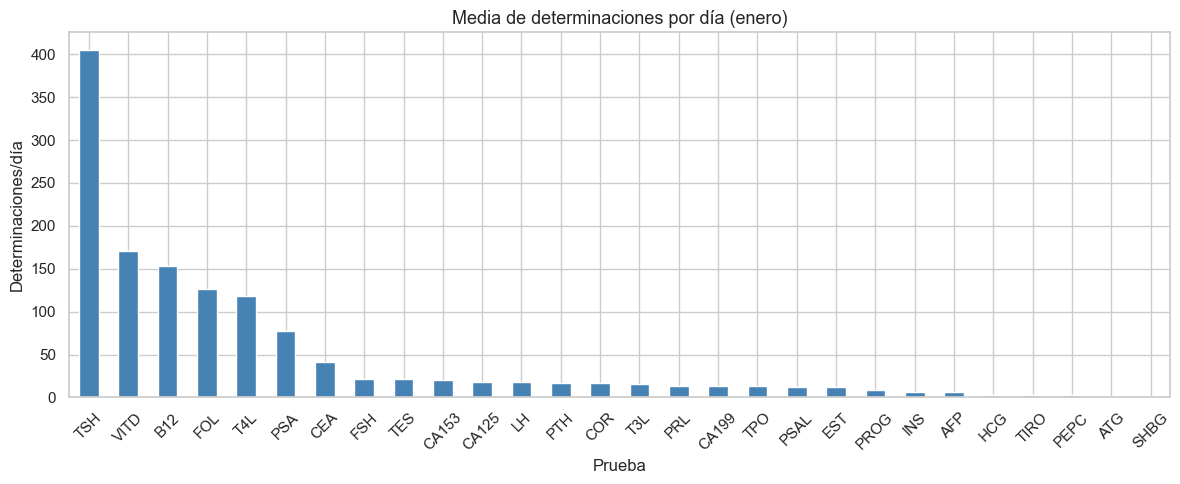

In [9]:
fig, ax = plt.subplots()
resumen_frecuencia['Media_dia'].plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Media de determinaciones por día (enero)', fontsize=13)
ax.set_xlabel('Prueba')
ax.set_ylabel('Determinaciones/día')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

---
## 4. Resultado 2 — Variabilidad diaria por prueba

In [10]:
por_dia = df.groupby(col_fecha)[pruebas].sum()

variabilidad = pd.DataFrame({
    'Media' : por_dia.mean().round(1),
    'Std'   : por_dia.std().round(2),
    'Min'   : por_dia.min(),
    'Max'   : por_dia.max(),
    'CV_%'  : (por_dia.std() / por_dia.mean() * 100).round(1)  # coeficiente de variación
}).sort_values('Media', ascending=False)

print("=== VARIABILIDAD DIARIA POR PRUEBA ===")
print(variabilidad.to_string())

=== VARIABILIDAD DIARIA POR PRUEBA ===
       Media     Std  Min  Max   CV_%
TSH    405.4  317.17    0  765   78.2
VITD   170.8  132.79    0  322   77.8
B12    153.5  119.35    0  300   77.7
FOL    126.1   98.25    0  260   77.9
T4L    118.2   92.49    0  240   78.3
PSA     77.7   61.04    0  149   78.5
CEA     41.7   32.79    0   88   78.6
FSH     21.5   17.33    0   45   80.4
TES     21.4   17.01    0   43   79.5
CA153   19.7   15.92    0   45   80.6
CA125   17.5   14.08    0   41   80.4
LH      17.5   14.29    0   41   81.9
PTH     17.1   17.50    0   74  102.1
COR     17.0   13.42    0   35   79.1
T3L     15.7   13.43    0   37   85.6
PRL     13.6   11.10    0   32   81.3
CA199   13.6   10.82    0   28   79.3
TPO     12.8   10.96    0   36   85.4
PSAL    12.6   10.76    0   32   85.3
EST     12.3   10.45    0   28   85.0
PROG     8.8    7.64    0   22   86.5
INS      6.7    5.93    0   17   88.4
AFP      6.2    5.34    0   15   86.3
HCG      2.7    2.74    0    8  100.1
TIRO     2.

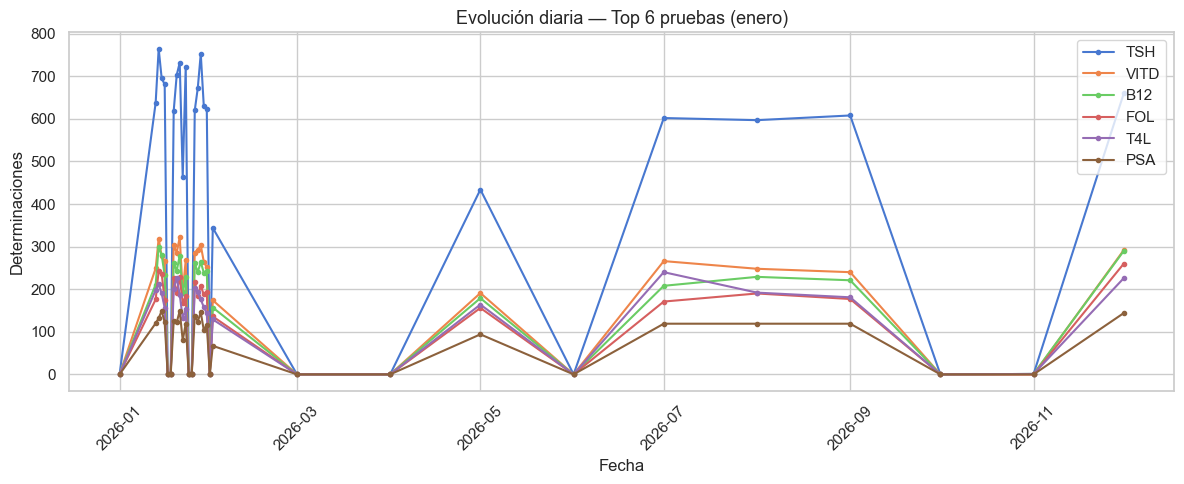

In [11]:
# Evolución diaria de las 6 pruebas más frecuentes
top6 = resumen_frecuencia.head(6).index.tolist()

fig, ax = plt.subplots()
for prueba in top6:
    ax.plot(por_dia.index, por_dia[prueba], marker='o', markersize=3, label=prueba)

ax.set_title('Evolución diaria — Top 6 pruebas (enero)', fontsize=13)
ax.set_xlabel('Fecha')
ax.set_ylabel('Determinaciones')
ax.legend(loc='upper right')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---
## 5. Resultado 3 — Matriz de co-ocurrencia de pruebas
Cuántas veces aparecen dos pruebas **en la misma petición**. Cuantifica la restricción *"pruebas frecuentes deben ir en conjunto"*.

In [23]:
# Construcción de la matriz de co-ocurrencia
mat = df_binario.values  # numpy array para mayor velocidad
cooc_matrix = mat.T @ mat  # producto matricial: cooc[i,j] = filas donde ambas son 1
np.fill_diagonal(cooc_matrix, 0)  # eliminamos la diagonal (prueba consigo misma)

cooc_df = pd.DataFrame(cooc_matrix, index=pruebas, columns=pruebas)


# Top pares
pares = []
for p1, p2 in combinations(pruebas, 2):
    val = cooc_df.loc[p1, p2]
    if val > 0:
        pares.append({'Prueba_1': p1, 'Prueba_2': p2, 'Co-ocurrencias': int(val)})

pares_df = pd.DataFrame(pares).sort_values('Co-ocurrencias', ascending=False).reset_index(drop=True)

print("=== TOP 20 PARES MÁS CO-OCURRENTES ===")
print(pares_df.head(20).to_string(index=False))

=== TOP 20 PARES MÁS CO-OCURRENTES ===
Prueba_1 Prueba_2  Co-ocurrencias
     TSH     VITD            3954
     FOL      B12            3758
     TSH      B12            3659
     TSH      T4L            3609
     FOL      TSH            2901
     B12     VITD            2458
     FOL     VITD            1782
     PSA      TSH            1652
     T4L      B12            1057
     T4L     VITD             989
     FOL      T4L             908
     CEA      TSH             636
     FSH      TSH             598
   CA153      CEA             590
     PSA     VITD             588
     PSA      B12             568
     FSH       LH             500
     CEA      T4L             500
     PTH     VITD             498
     T3L      T4L             486


In [24]:

no_big_six = [p for p in pruebas if p not in ["TSH", "FOL", "VITD", "B12", "T4L", "PSA"]]
# 1. Filtrar el DataFrame binario para quedarte solo con las especialidades
df_especialidad_bin = df_binario[no_big_six]

# 2. Construir la matriz directamente sobre ese subconjunto
mat_esp = df_especialidad_bin.values
cooc_matrix = mat_esp.T @ mat_esp
np.fill_diagonal(cooc_matrix, 0)

# 3. Crear el DataFrame de co-ocurrencia (ya filtrado)
cooc_df = pd.DataFrame(cooc_matrix, index=no_big_six, columns=no_big_six)
# Top pares
pares = []
for p1, p2 in combinations(no_big_six, 2):
    val = cooc_df.loc[p1, p2]
    if val > 0:
        pares.append({'Prueba_1': p1, 'Prueba_2': p2, 'Co-ocurrencias': int(val)})

pares_df = pd.DataFrame(pares).sort_values('Co-ocurrencias', ascending=False).reset_index(drop=True)

print("=== TOP 20 PARES MÁS CO-OCURRENTES ===")
print(pares_df.head(20).to_string(index=False))

=== TOP 20 PARES MÁS CO-OCURRENTES ===
Prueba_1 Prueba_2  Co-ocurrencias
   CA153      CEA             590
     FSH       LH             500
   CA199      CEA             381
     EST      FSH             368
     EST       LH             336
      LH      PRL             305
      LH      TES             305
     FSH      PRL             301
     FSH      TES             277
     FSH     PROG             258
      LH     PROG             257
   CA125      CEA             236
     PRL      TES             211
     EST      PRL             208
     EST      TES             205
     EST     PROG             201
    PROG      PRL             180
    PROG      TES             176
     CEA      FSH             143
   CA125    CA199             136


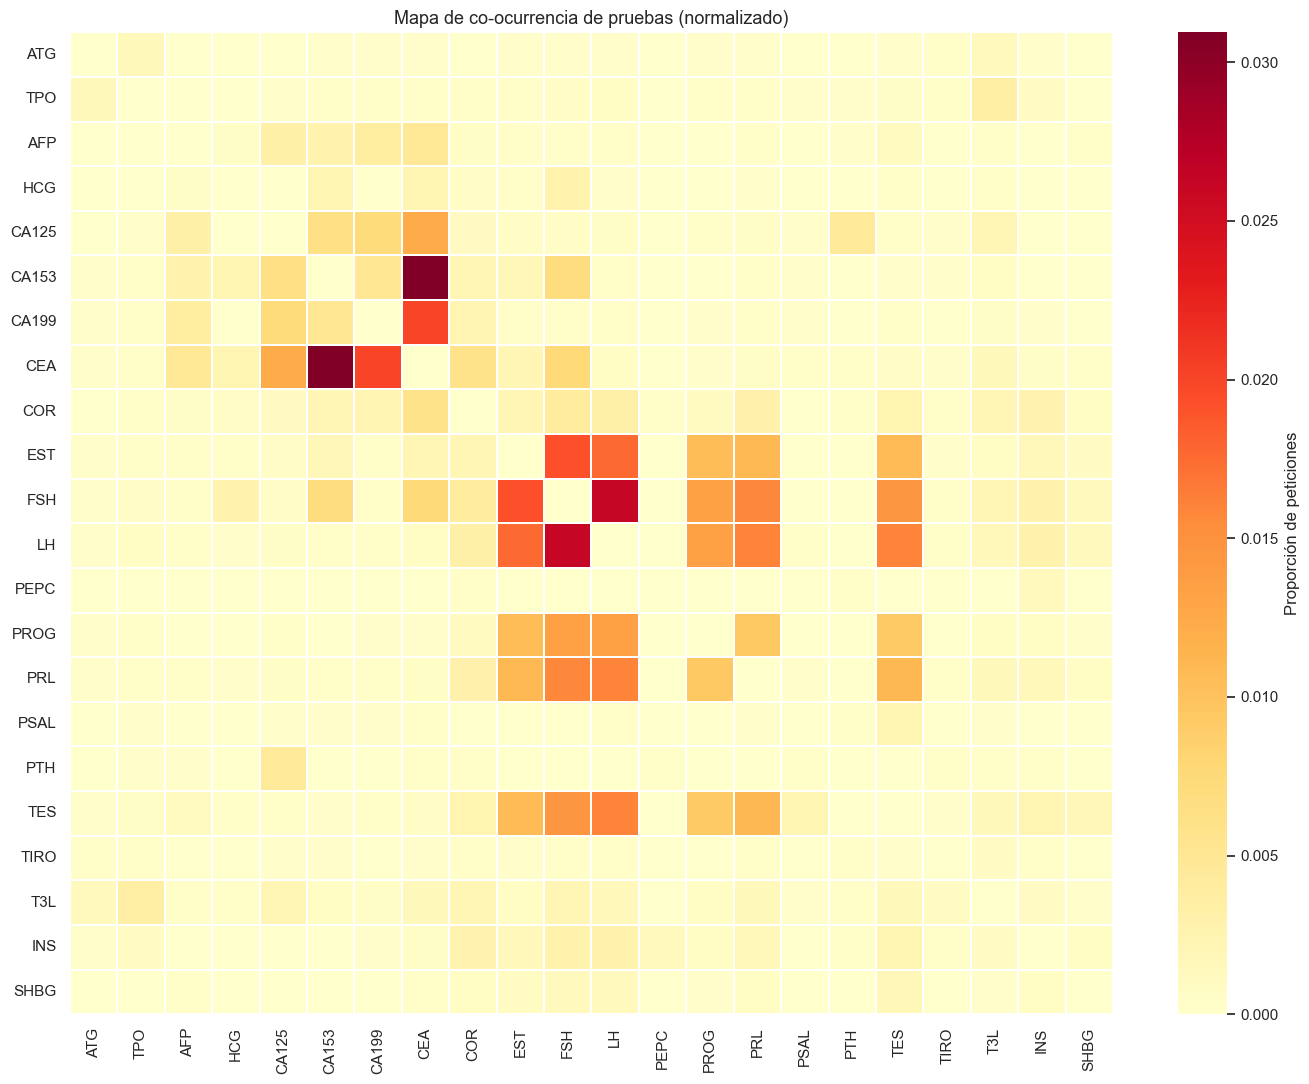

In [25]:
# Heatmap de co-ocurrencia (normalizado por el total de peticiones)
cooc_norm = cooc_df / len(df_binario)  # proporción de peticiones donde co-ocurren

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(
    cooc_norm,
    ax=ax,
    cmap='YlOrRd',
    linewidths=0.3,
    annot=False,
    fmt='.2f',
    cbar_kws={'label': 'Proporción de peticiones'}
)
ax.set_title('Mapa de co-ocurrencia de pruebas (normalizado)', fontsize=13)
plt.tight_layout()
plt.show()

---
## 5b. Resultado 3b — Co-ocurrencias en grupos de tamaño ≥ 3
Extiende el análisis anterior a **tripletas, cuartetos y quíntuplos**: cuántas peticiones contienen simultáneamente todas las pruebas del grupo. Grupos con alta co-ocurrencia deben poder resolverse en el mismo analizador (o en analizadores capaces) para minimizar tiempos de respuesta.

In [28]:
# 1. Crear la matriz booleana SOLO con las pruebas que no son Big 6
mat_bool_especialidad = df_binario[no_big_six].values.astype(bool) 

def top_coocurrencias(tamanyo, top_n=20):
    filas = []
    # Ahora los índices de 'grupo' coincidirán perfectamente con 'mat_bool_especialidad'
    for grupo in combinations(range(len(no_big_six)), tamanyo):
        cuenta = mat_bool_especialidad[:, grupo].all(axis=1).sum()
        if cuenta > 0:
            filas.append({
                'Grupo': ' + '.join(no_big_six[i] for i in grupo), 
                'Co-ocurrencias': int(cuenta)
            })
    return (pd.DataFrame(filas)
              .sort_values('Co-ocurrencias', ascending=False)
              .head(top_n)
              .reset_index(drop=True))

# --- Tripletas ---
print("=== TOP 20 TRIPLETAS ===")
tripletas_df = top_coocurrencias(3, top_n=20)
print(tripletas_df.to_string(index=False))

# --- Cuartetos ---
print("\n=== TOP 20 CUARTETOS ===")
cuartetos_df = top_coocurrencias(4, top_n=20)
print(cuartetos_df.to_string(index=False))

# --- Quíntuplos ---
print("\n=== TOP 20 QUÍNTUPLOS ===")
quintuplos_df = top_coocurrencias(5, top_n=20)
print(quintuplos_df.to_string(index=False))

=== TOP 20 TRIPLETAS ===
            Grupo  Co-ocurrencias
   EST + FSH + LH             331
   FSH + LH + PRL             288
   FSH + LH + TES             270
  FSH + LH + PROG             251
  EST + FSH + PRL             202
   EST + LH + PRL             200
  EST + LH + PROG             198
 EST + FSH + PROG             197
  EST + FSH + TES             197
   EST + LH + TES             196
   LH + PRL + TES             183
  FSH + PRL + TES             175
  LH + PROG + PRL             172
 FSH + PROG + PRL             171
 FSH + PROG + TES             170
  LH + PROG + TES             170
 EST + PROG + TES             143
 EST + PROG + PRL             134
CA153 + CEA + FSH             133
  EST + PRL + TES             131

=== TOP 20 CUARTETOS ===
                      Grupo  Co-ocurrencias
       EST + FSH + LH + PRL             196
      EST + FSH + LH + PROG             195
       EST + FSH + LH + TES             194
       FSH + LH + PRL + TES             169
      FSH + LH 

---
## 6. Resultado 4 — Tamaño típico de petición
¿Cuántas pruebas se piden habitualmente en una misma petición?

In [15]:
pruebas_por_peticion = df_binario.sum(axis=1)

distribucion = pruebas_por_peticion.value_counts().sort_index()
print("Nº de pruebas por petición  |  Frecuencia")
print(distribucion.to_string())
print(f"\nMedia: {pruebas_por_peticion.mean():.2f}  |  Mediana: {pruebas_por_peticion.median():.0f}  |  Máx: {pruebas_por_peticion.max()}")

Nº de pruebas por petición  |  Frecuencia
0     2758
1     5595
2     4046
3     2688
4     2152
5      876
6      471
7      235
8       99
9       64
10      46
11      18
12      11
13       6
14       1
17       1

Media: 2.18  |  Mediana: 2  |  Máx: 17


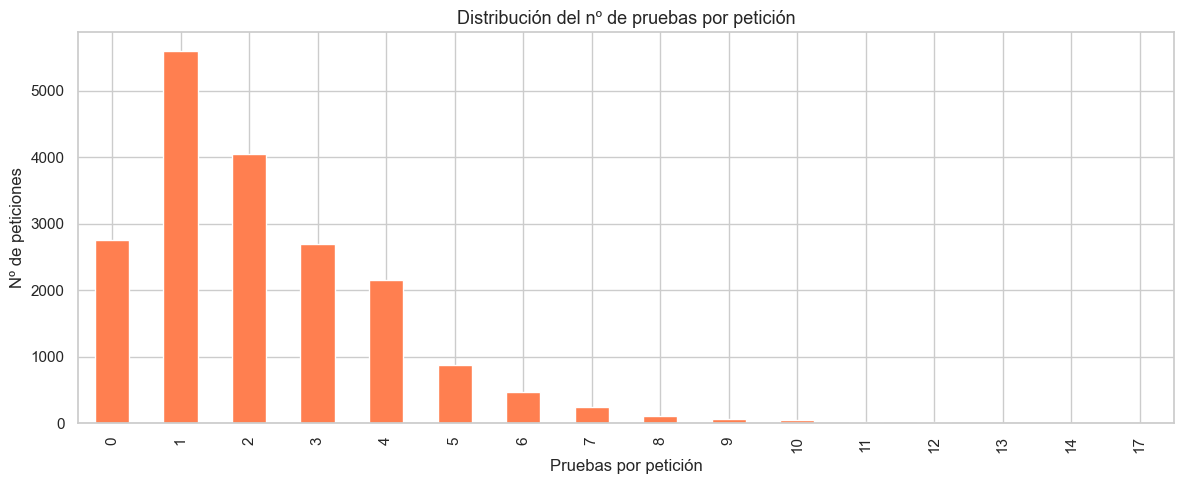

In [16]:
fig, ax = plt.subplots()
distribucion.plot(kind='bar', ax=ax, color='coral', edgecolor='white')
ax.set_title('Distribución del nº de pruebas por petición', fontsize=13)
ax.set_xlabel('Pruebas por petición')
ax.set_ylabel('Nº de peticiones')
plt.tight_layout()
plt.show()

---
## 7. Resultado 5 — Carga estimada por analizador (placeholder)

> Esta celda está preparada para cuando tengas la **matriz de compatibilidad** (qué pruebas puede hacer cada DX).  
> Sustituye el diccionario `compatibilidad` con los datos reales del laboratorio.

In [17]:
# PLACEHOLDER — editar con datos reales cuando se dispongan
# Formato: { 'CODIGO_PRUEBA': ['DX1', 'DX2'] }  → pruebas que pueden hacerse en esos analizadores

compatibilidad = {
    # 'TSH'  : ['DX1', 'DX2'],
    # 'T4L'  : ['DX1', 'DX2', 'DX3'],
    # 'B12'  : ['DX3'],
    # ...etc
}

if compatibilidad:
    carga = {dx: 0 for dx in ['DX1', 'DX2', 'DX3']}
    for prueba, dxs in compatibilidad.items():
        if prueba in resumen_frecuencia.index:
            vol = resumen_frecuencia.loc[prueba, 'Media_dia']
            for dx in dxs:
                carga[dx] += vol / len(dxs)  # distribución equitativa como estimación inicial
    print("Carga estimada (det/día) por analizador con distribución equitativa:")
    for dx, val in carga.items():
        print(f"  {dx}: {val:.1f} det/día")
else:
    print("⚠️  Rellena el diccionario 'compatibilidad' con los datos del laboratorio para activar esta celda.")

⚠️  Rellena el diccionario 'compatibilidad' con los datos del laboratorio para activar esta celda.


---
## 8. Exportar resultados a Excel
Genera un fichero con todas las tablas para entregar o revisar.

In [18]:
with pd.ExcelWriter('resultados_preprocesamiento.xlsx', engine='openpyxl') as writer:
    resumen_frecuencia.to_excel(writer, sheet_name='Frecuencia_mes')
    variabilidad.to_excel(writer, sheet_name='Variabilidad_diaria')
    pares_df.to_excel(writer, sheet_name='Co-ocurrencia_pares', index=False)
    distribucion.to_frame(name='Frecuencia').to_excel(writer, sheet_name='Tamano_peticion')
    cooc_df.to_excel(writer, sheet_name='Matriz_coocurrencia')

print("✅ Archivo 'resultados_preprocesamiento.xlsx' generado correctamente.")

ModuleNotFoundError: No module named 'openpyxl'

---
## Notas finales

Una vez ejecutado este notebook, los datos clave para el modelo de optimización son:

| Dato obtenido | Dónde se usa en el modelo |
|---|---|
| Media diaria por prueba | Parámetro de demanda $d_i$ |
| Variabilidad diaria (CV%) | Robustez del modelo / escenario pico |
| Co-ocurrencia de pares | Restricción de agrupación de pruebas |
| Tamaño típico de petición | Estructura de las variables de decisión |

**Pendiente del laboratorio** para completar el modelo:
- Matriz de compatibilidad prueba × analizador
- Determinaciones por petaca por prueba
- Velocidad de procesado (det/hora) de cada DX
- Configuración actual (situación de partida)